### 【[K線捕手](https://www.facebook.com/kevinyang20180801)盤前快訊】支撐有守，尚未翻多  
因為明早開盤前就會出門，所以今晚提早寫盤勢的分享。加權指數今天出現很戲劇性的走勢，早盤開低之後跌點擴大，最低下跌88點，10點過後開始出現反彈，終場逆勢翻紅收漲58點。  
周末以來提到的日股、台幣、加權指數，個別的關鍵支撐，目前暫時也都有守住。大家一定很好奇，今天先下跌後又拉下影線，又剛好是關鍵支撐和壓力區，會不會是止跌訊號？  
當然台股當然在國際股市中還是相對強勢，僅次於日本的表現，雖然看似很巧妙地守在關鍵位置，但這不是台股獨有的現象，而是亞股同步轉強。  
國際指數也有部分因為先跌，短線有機會先止跌，例如：道瓊、德國、韓國、香港，而台股中雖然類股結構幾乎都偏空方，但是不少類股因為連續下跌也接近短線支撐，或是頭部跌幅滿足，因此有助於空方力量減緩。  
加權指數短線雖然暫時守住中期支撐，但5個多月的頭部雛形仍在，所以止穩有餘，要說翻多還言之過早，先前已經出現月線和季線死亡交叉、月線和半年線死亡交叉，接下來即將出現季線和半年線的死亡交叉，往上仍是反壓重重。 (出處：K線捕手楊忠憲粉絲團)  
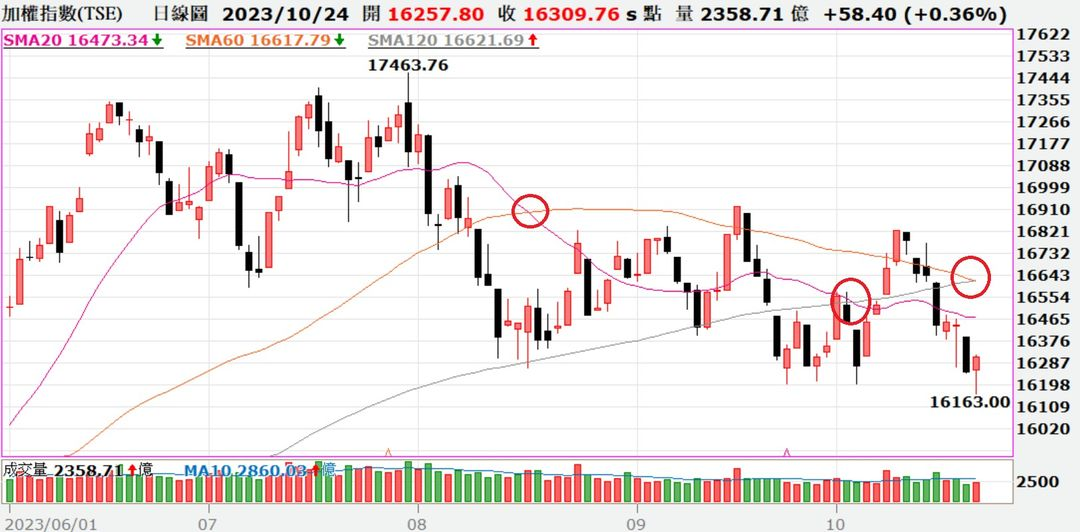

日韓股市都開高上漲：  
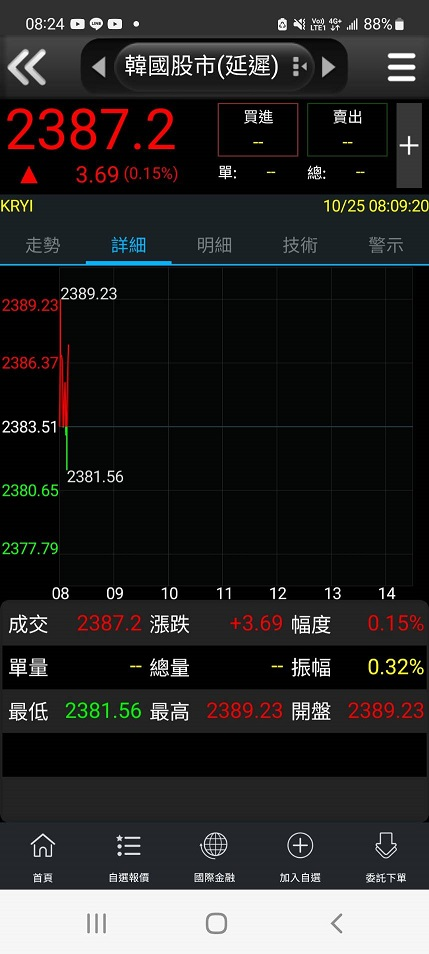  
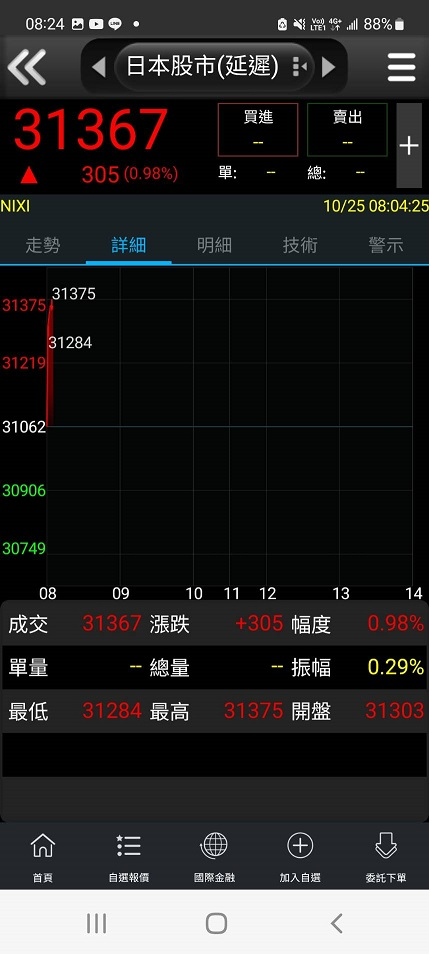  
  
期貨 小漲：  
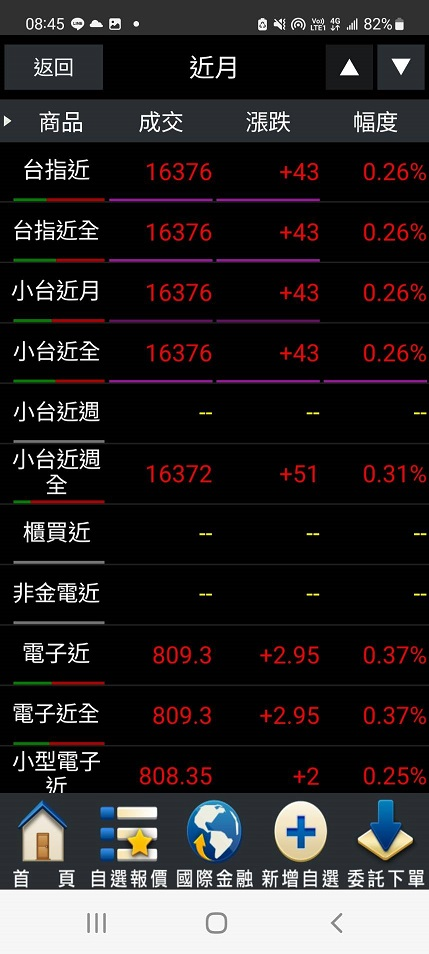  
  
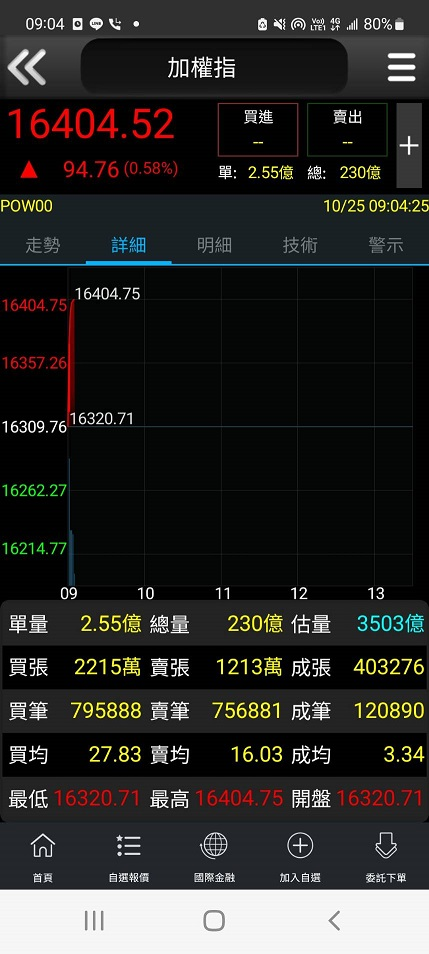  
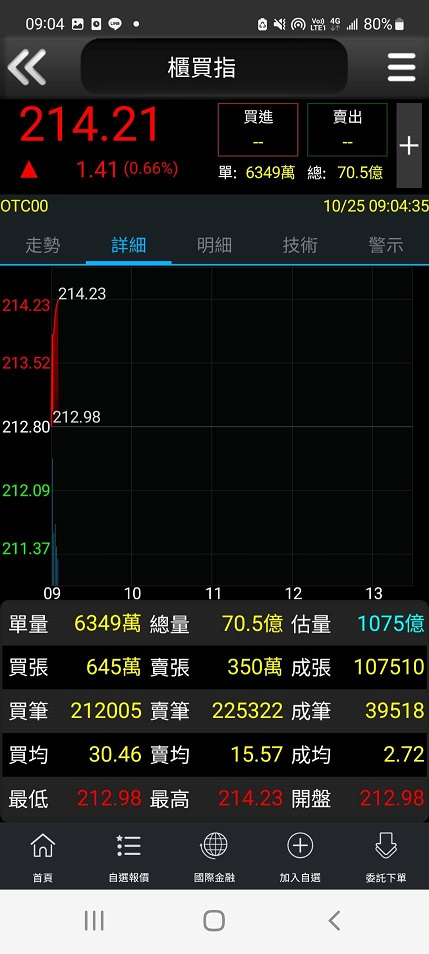  
  
量能不足，遇壓小回  
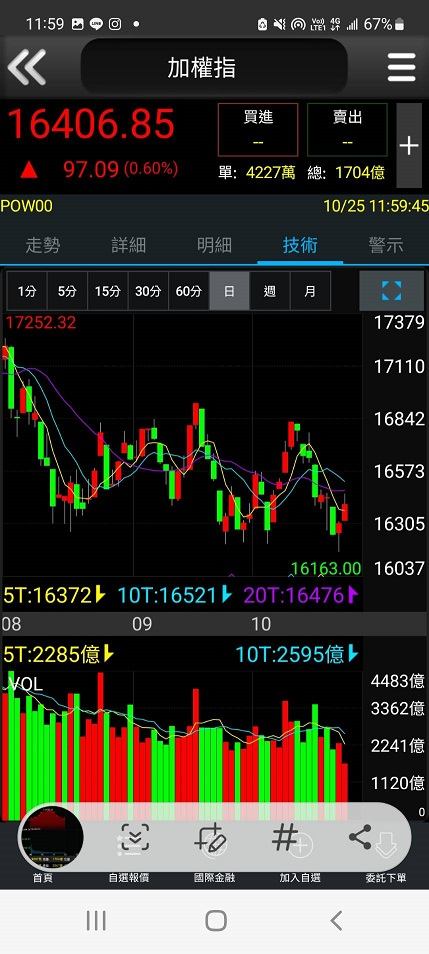  
  
韓國也是遇壓拉回：  
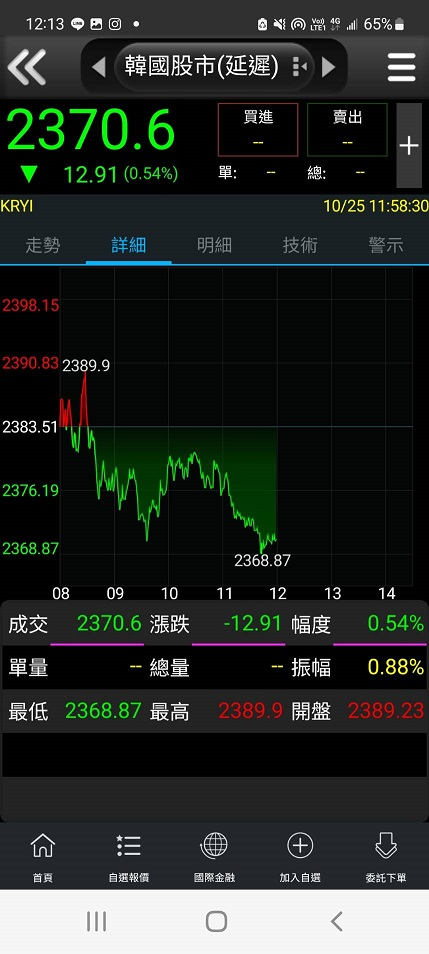

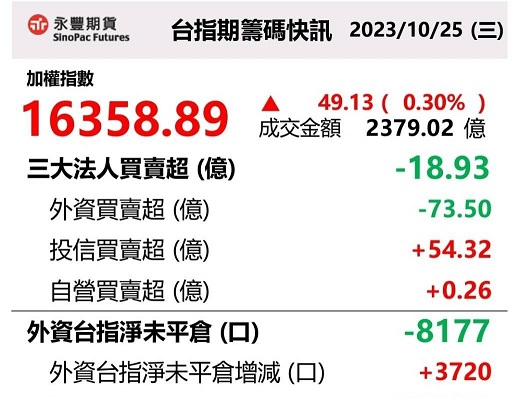  
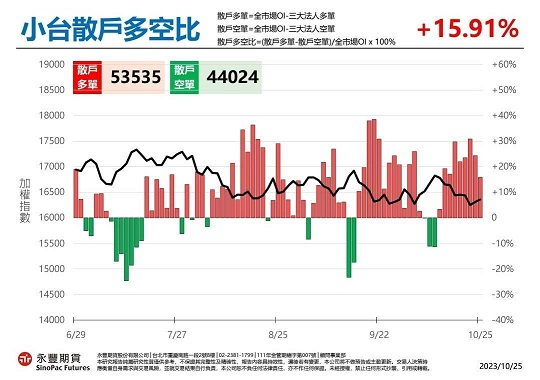  

### 本日進度  
* **暫時空手**，觀察後續盤勢發展。  
* 追蹤：麗臺(2465)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np

In [2]:
##### 使用2021年12月21日到今日收盤(2023年10月25日)之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_2465_231025.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

頸線價格 ＝ 43.10 ； 目標價 ＝ 62.45元


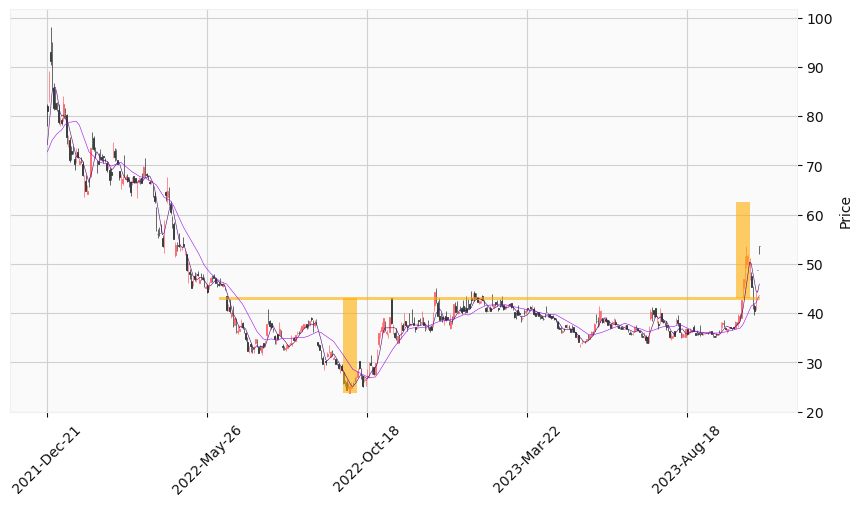

In [3]:
# 設定頸線
neckline_price = df_k_line.loc['2022-11-08']['Open']
neckline_start_date = '2022-06-07'
neckline_end_date = '2023-10-25'

# 估算目標價
bottom_price_date = '2022-09-30'
bottom_price = df_k_line.loc[bottom_price_date]['Open']
target_price = (neckline_price - bottom_price) + neckline_price
print('頸線價格 ＝ {:.2f} ； 目標價 ＝ {:.2f}元'.format(neckline_price,target_price))
target_price_date = '2023-10-11'

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
    [(bottom_price_date,bottom_price),(bottom_price_date,neckline_price)],
    [(target_price_date,target_price),(target_price_date,neckline_price)]
                     ]


# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.4,color='xkcd:royal purple'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.4,color='xkcd:violet')
            }

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=(1.0,10,10), colors='xkcd:orange yellow', alpha=0.6))
mpf.plot(df_k_line,**kwargs)